# Understanding the Coefficents

## Prereqs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define Shapes
shape_names = ["Ellipse", "Rectangle", "Annulus (Ring)", "Two Circles"]

shapes = [
    {
        "type": "ellipse",
        "a": 0.6, "b": 0.3,
        "theta": np.pi/4,
        "center": (0.0, 0.0),
    },
    {
        "type": "rectangle",
        "width": 0.8, "height": 0.4,
        "theta": np.pi/6,
        "center": (0.0, 0.0),
    },
    {
        "type": "annulus",
        "outer_radius": 0.7,
        "inner_radius": 0.3,
        "center": (0.0, 0.0),
    },
    {
        "type": "two_circles",
        "radius1": 0.3, "center1": (-0.4, 0.3),
        "radius2": 0.25, "center2": (0.4, -0.2),
    },
]


def compute_mask(shape, X, Y):
    t = shape["type"]
    match t:
        case "ellipse":
            a = shape["a"]
            b = shape["b"]
            theta = shape["theta"]
            cx, cy = shape["center"]
            x_shift = X - cx
            y_shift = Y - cy
            x_rot = x_shift * np.cos(theta) + y_shift * np.sin(theta)
            y_rot = -x_shift * np.sin(theta) + y_shift * np.cos(theta)
            mask = (x_rot / a) ** 2 + (y_rot / b) ** 2 <= 1.0
            return mask
        case "rectangle":
            width = shape["width"]
            height = shape["height"]
            theta = shape["theta"]
            cx, cy = shape["center"]
            x_shift = X - cx
            y_shift = Y - cy
            x_rot = x_shift * np.cos(theta) + y_shift * np.sin(theta)
            y_rot = -x_shift * np.sin(theta) + y_shift * np.cos(theta)
            mask = (np.abs(x_rot) <= width / 2) & (np.abs(y_rot) <= height / 2)
            return mask
        case "annulus":
            outer_radius = shape["outer_radius"]
            inner_radius = shape["inner_radius"]
            cx, cy = shape["center"]
            dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
            mask = (dist <= outer_radius) & (dist >= inner_radius)
            return mask
        case "two_circles":
            radius1 = shape["radius1"]
            cx1, cy1 = shape["center1"]
            radius2 = shape["radius2"]
            cx2, cy2 = shape["center2"]
            dist1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
            dist2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
            mask = (dist1 <= radius1) | (dist2 <= radius2)
            return mask
        case _:
            raise ValueError(f"Unsupported shape type: {t}")

## Setup

In [ ]:
grid_size = 200
x = np.linspace(-1, 1, grid_size)
X, Y = np.meshgrid(x, x)
dx = x[1] - x[0]
dA = dx**2

D = {
        "type": "ellipse",
        "a": 0.6, "b": 0.3,
        "theta": np.pi/4,
        "center": (0.1, 0.1),
    }

# Compute Mask
mask = compute_mask(D, X, Y)

# Complex grid
z = X + 1j*Y 

## Computing Coefficets

In [ ]:
N_max = 5
coeff = np.zeros(N_max + 1, dtype=np.complex128)
for n in range(N_max + 1):
    integrand = (z**n) * mask
    coeff[n] = (1 / (4 * np.pi)) * np.sum(integrand) * dA

## Visualization

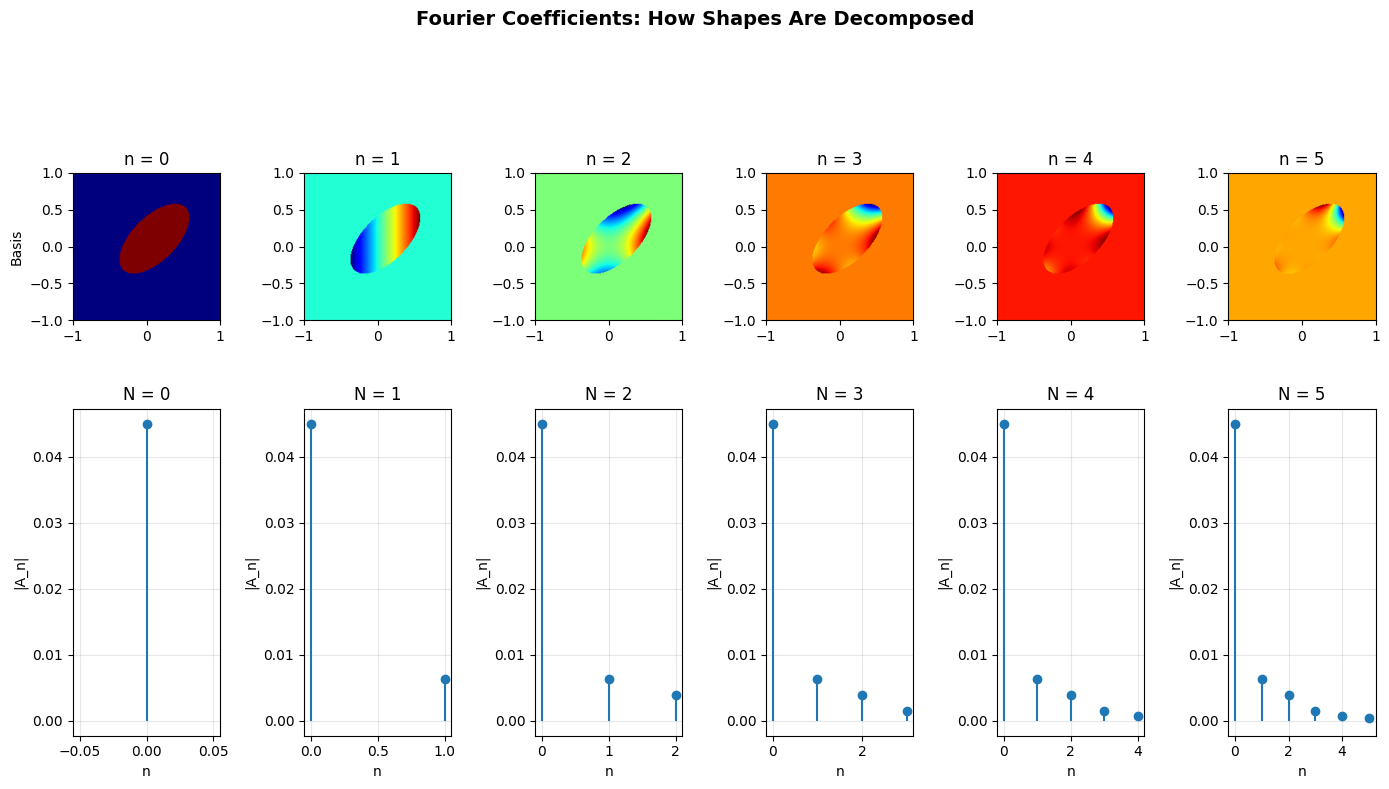

In [ ]:
N_values = range(0, 6)
fig = plt.figure(figsize=(14, 8))
for idx, N in enumerate(N_values, start=1):
    # Basis function for current N
    ax1 = fig.add_subplot(2, 6, idx)
    basis = np.real(z**N) * mask
    im = ax1.imshow(
        basis,
        extent=[x.min(), x.max(), x.min(), x.max()],
        origin="lower",
        cmap="jet"
    )
    ax1.set_title(f"n = {N}")
    ax1.set_aspect("equal")
    if idx == 1:
        ax1.set_ylabel("Basis")
    # Coefficient magnitudes up to N
    ax2 = fig.add_subplot(2, 6, 6 + idx)
    k = np.arange(N + 1)
    ax2.stem(k, np.abs(coeff[:N+1]), basefmt=" ")
    ax2.set_xlabel("n")
    ax2.set_ylabel("|A_n|")
    ax2.set_title(f"N = {N}")
    ax2.grid(True, alpha=0.3)
fig.suptitle("Fourier Coefficients: How Shapes Are Decomposed", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Coefficent Table

In [ ]:
print("\n=== FOURIER COEFFICIENTS FOR THE ELLIPSE ===\n")
print("n\tReal\t\tImaginary\tMagnitude")
print("-\t----\t\t---------\t---------")
for n in range(N_max + 1):
    print(f"{n}\t{coeff[n].real:+.4f}\t\t{coeff[n].imag:+.4f}\t\t{abs(coeff[n]):.4f}")


=== FOURIER COEFFICIENTS FOR THE ELLIPSE ===

n	Real		Imaginary	Magnitude
-	----		---------	---------
0	+0.0450		+0.0000		0.0450
1	+0.0045		+0.0045		0.0064
2	+0.0000		+0.0039		0.0039
3	-0.0010		+0.0010		0.0014
4	-0.0008		+0.0000		0.0008
5	-0.0003		-0.0003		0.0004


## Exersizes

In [ ]:
# Helper Function
def compute_coefficients(mask, X, Y, dA, N_max=5):
    z = X + 1j * Y
    coeff = np.zeros(N_max + 1, dtype=np.complex128)
    for n in range(N_max + 1):
        integrand = (z**n) * mask
        coeff[n] = (1 / (4 * np.pi)) * np.sum(integrand) * dA
    return coeff

In [ ]:
exercise_shapes = [
    {
        "name": "Exercise 1: Thin Ellipse",
        "shape": {
            "type": "ellipse",
            "a": 0.8,
            "b": 0.1,
            "theta": np.pi/4,
            "center": (0.1, 0.1),
        },
    },
    {
        "name": "Exercise 2: Circle",
        "shape": {
            "type": "ellipse",
            "a": 0.5,
            "b": 0.5,
            "theta": np.pi/4,
            "center": (0.1, 0.1),
        },
    },
    {
        "name": "Exercise 3: Rotated Ellipse",
        "shape": {
            "type": "ellipse",
            "a": 0.6,
            "b": 0.3,
            "theta": np.pi/2,
            "center": (0.1, 0.1),
        },
    },
    {
        "name": "Exercise 4: Shifted Ellipse",
        "shape": {
            "type": "ellipse",
            "a": 0.6,
            "b": 0.3,
            "theta": np.pi/4,
            "center": (0.6, 0.6),
        },
    },
]


=== Exercise 1: Thin Ellipse ===
n	Real		Imag		|A_n|
0	+0.0200		+0.0000		0.0200
1	+0.0020		+0.0020		0.0028
2	+0.0000		+0.0036		0.0036
3	-0.0010		+0.0010		0.0014
4	-0.0014		+0.0000		0.0014
5	-0.0006		-0.0006		0.0008

=== Exercise 2: Circle ===
n	Real		Imag		|A_n|
0	+0.0626		+0.0000		0.0626
1	+0.0063		+0.0063		0.0089
2	+0.0000		+0.0013		0.0013
3	-0.0001		+0.0001		0.0002
4	-0.0000		-0.0000		0.0000
5	-0.0000		-0.0000		0.0000

=== Exercise 3: Rotated Ellipse ===
n	Real		Imag		|A_n|
0	+0.0450		+0.0000		0.0450
1	+0.0045		+0.0045		0.0064
2	-0.0030		+0.0009		0.0032
3	-0.0010		-0.0008		0.0013
4	+0.0004		-0.0004		0.0005
5	+0.0003		+0.0001		0.0003

=== Exercise 4: Shifted Ellipse ===
n	Real		Imag		|A_n|
0	+0.0421		+0.0000		0.0421
1	+0.0243		+0.0243		0.0343
2	+0.0000		+0.0303		0.0303
3	-0.0201		+0.0201		0.0285
4	-0.0281		-0.0000		0.0281
5	-0.0203		-0.0203		0.0287


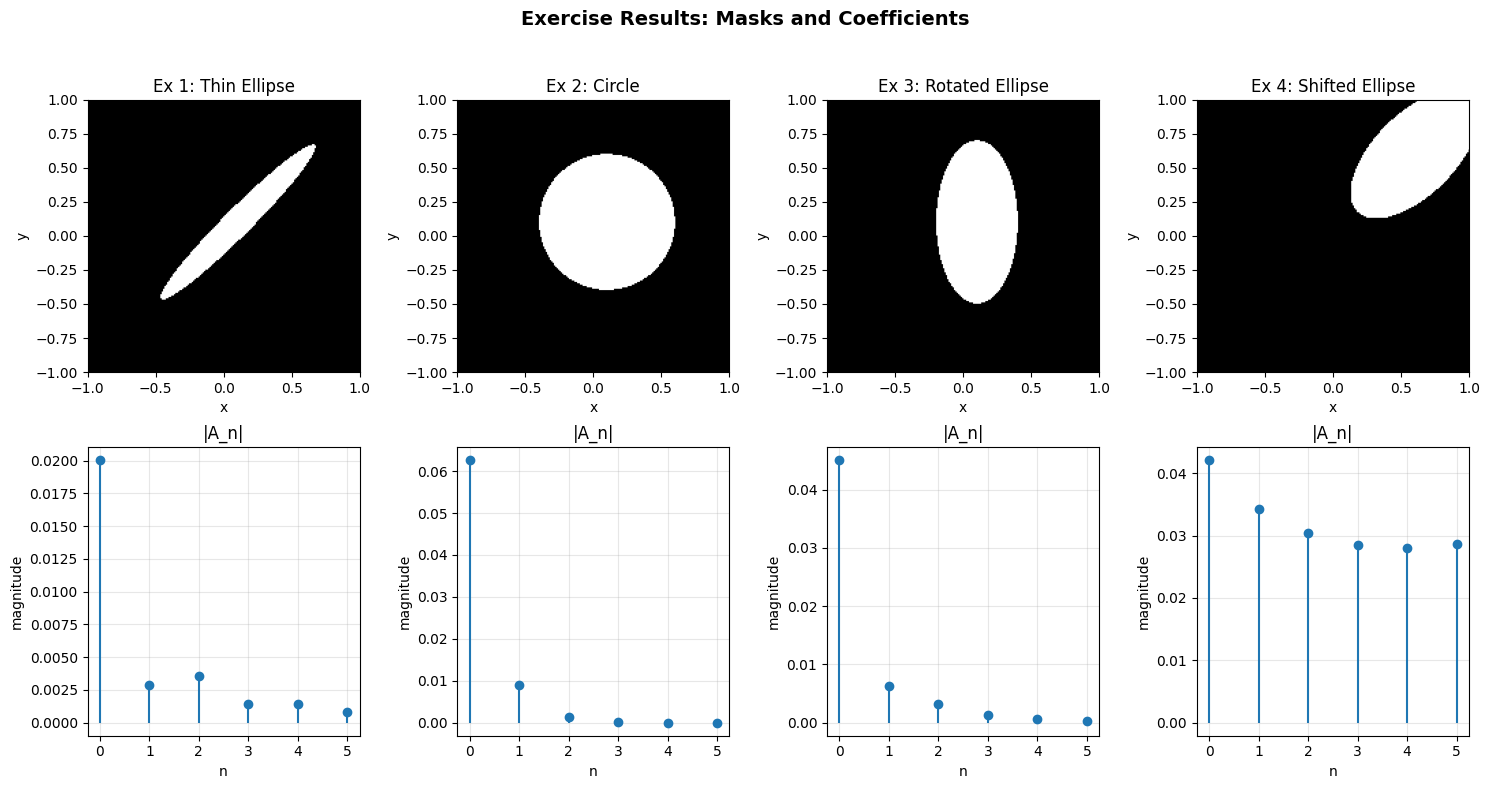

In [ ]:
N_max = 5
fig = plt.figure(figsize=(15, 8))
for i, ex in enumerate(exercise_shapes, start=1):
    name = ex["name"]
    shape = ex["shape"]
    mask = compute_mask(shape, X, Y)
    coeff = compute_coefficients(mask, X, Y, dA, N_max=N_max)
    # Plot mask
    ax1 = fig.add_subplot(2, 4, i)
    ax1.imshow(mask.astype(float), extent=[x.min(), x.max(), x.min(), x.max()],
               origin="lower", cmap="gray")
    ax1.set_title(name.replace("Exercise ", "Ex "))
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_aspect("equal")
    # Plot coefficient magnitudes
    ax2 = fig.add_subplot(2, 4, i + 4)
    n_vals = np.arange(N_max + 1)
    ax2.stem(n_vals, np.abs(coeff), basefmt=" ")
    ax2.set_title("|A_n|")
    ax2.set_xlabel("n")
    ax2.set_ylabel("magnitude")
    ax2.grid(True, alpha=0.3)
    # Print coefficient table
    print(f"\n=== {name} ===")
    print("n\tReal\t\tImag\t\t|A_n|")
    for n in range(N_max + 1):
        print(f"{n}\t{coeff[n].real:+.4f}\t\t{coeff[n].imag:+.4f}\t\t{abs(coeff[n]):.4f}")
fig.suptitle("Exercise Results: Masks and Coefficients", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()